# Modeling: multiple regressors (includes XGBoost)

This notebook loads `bengaluru_wards_dataset.csv`, performs preprocessing and feature engineering, trains several regressors (including XGBoost if available), evaluates them, and saves the trained models.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

# Optional XGBoost
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    print('XGBoost not available; it will be skipped if not installed.')

sns.set_style('whitegrid')

In [ ]:
# Load dataset
df = pd.read_csv('bengaluru_wards_dataset.csv')
print(f'Dataset rows: {len(df)}, columns: {list(df.columns)}')
if 'Date' not in df.columns:
    df['Date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))
else:
    df['Date'] = pd.to_datetime(df['Date'])

df.head()

Dataset rows: 7128, columns: ['Ward_ID', 'Year', 'Month', 'Rainfall_mm', 'Avg_Temp_C', 'Garbage_Complaints', 'Waterlogging_Complaints', 'Dengue_Cases', 'Risk_Level', 'Date']


,Ward_ID,Year,Month,Rainfall_mm,Avg_Temp_C,Garbage_Complaints,Waterlogging_Complaints,Dengue_Cases,Risk_Level,Date
0,1,2021,1,5.7,20.4,35,5,22,Medium,2021-01-01
1,1,2021,2,14.5,18.3,25,4,11,Low,2021-02-01
2,1,2021,3,5.1,32.6,20,3,15,Low,2021-03-01
3,1,2021,4,1.2,38.3,21,7,16,Low,2021-04-01
4,1,2021,5,98.0,32.5,20,16,18,Low,2021-05-01


## Preprocessing & Feature Engineering

In [3]:
df_fe = df.sort_values(['Ward_ID','Date']).reset_index(drop=True).copy()
# Lag features
df_fe['Rainfall_Lag1'] = df_fe.groupby('Ward_ID')['Rainfall_mm'].shift(1)
df_fe['Rainfall_Lag2'] = df_fe.groupby('Ward_ID')['Rainfall_mm'].shift(2)
df_fe['Temp_Lag1'] = df_fe.groupby('Ward_ID')['Avg_Temp_C'].shift(1)
df_fe['Cases_Lag1'] = df_fe.groupby('Ward_ID')['Dengue_Cases'].shift(1)
# Rolling means (3-month)
df_fe['Rainfall_roll3_mean'] = df_fe.groupby('Ward_ID')['Rainfall_mm'].rolling(window=3, min_periods=1).mean().reset_index(0,drop=True)
df_fe['Cases_roll3_mean'] = df_fe.groupby('Ward_ID')['Dengue_Cases'].rolling(window=3, min_periods=1).mean().reset_index(0,drop=True)
# Temporal
df_fe['Month'] = df_fe['Date'].dt.month
df_fe['Year'] = df_fe['Date'].dt.year
df_fe['Is_Monsoon'] = df_fe['Month'].isin([6,7,8,9]).astype(int)
# Ward-level aggregates
ward_agg = df_fe.groupby('Ward_ID')[['Garbage_Complaints','Waterlogging_Complaints']].mean().rename(columns=lambda x: x+'_ward_mean')
df_fe = df_fe.merge(ward_agg, left_on='Ward_ID', right_index=True)
# Drop NA from lags
df_fe = df_fe.dropna().reset_index(drop=True)
print('After FE rows:', len(df_fe))
df_fe.head()

After FE rows: 6732


,Ward_ID,Year,Month,Rainfall_mm,Avg_Temp_C,Garbage_Complaints,Waterlogging_Complaints,Dengue_Cases,Risk_Level,Date,Rainfall_Lag1,Rainfall_Lag2,Temp_Lag1,Cases_Lag1,Rainfall_roll3_mean,Cases_roll3_mean,Is_Monsoon,Garbage_Complaints_ward_mean,Waterlogging_Complaints_ward_mean
0,1,2021,3,5.1,32.6,20,3,15,Low,2021-03-01,14.5,5.7,18.3,11.0,8.433333,16.000000,0,23.333333,11.222222
1,1,2021,4,1.2,38.3,21,7,16,Low,2021-04-01,5.1,14.5,32.6,15.0,6.933333,14.000000,0,23.333333,11.222222
2,1,2021,5,98.0,32.5,20,16,18,Low,2021-05-01,1.2,5.1,38.3,16.0,34.766667,16.333333,0,23.333333,11.222222
3,1,2021,6,150.3,24.0,6,17,36,Medium,2021-06-01,98.0,1.2,32.5,18.0,83.166667,23.333333,1,23.333333,11.222222
4,1,2021,7,102.9,28.3,38,18,68,High,2021-07-01,150.3,98.0,24.0,36.0,117.066667,40.666667,1,23.333333,11.222222


## Feature selection and train/test split

In [4]:
features = [
    'Rainfall_mm','Avg_Temp_C','Garbage_Complaints','Waterlogging_Complaints',
    'Rainfall_Lag1','Rainfall_Lag2','Temp_Lag1','Cases_Lag1',
    'Rainfall_roll3_mean','Cases_roll3_mean','Is_Monsoon','Garbage_Complaints_ward_mean','Waterlogging_Complaints_ward_mean'
]
target = 'Dengue_Cases'
X = df_fe[features].copy()
y = df_fe[target].copy()
# One-hot month (if desired) - keep numeric month out to keep simplicity
# X = pd.get_dummies(X, columns=['Month'], prefix='M', drop_first=True)
# Chronological split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_train, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()
print(f'Train rows: {len(X_train)}, Test rows: {len(X_test)}')

Train rows: 5385, Test rows: 1347


In [5]:
# Scale for linear/MLP
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
joblib.dump(scaler, 'scaler.joblib')
# Prepare model inputs
X_tree_train, X_tree_test = X_train, X_test
X_lin_train, X_lin_test = X_train_scaled, X_test_scaled
models = {}
if HAS_XGB:
    models['xgboost'] = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42)
models['random_forest'] = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
models['gbm'] = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
models['linear'] = LinearRegression()
models['mlp'] = MLPRegressor(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
list(models.keys())

['xgboost', 'random_forest', 'gbm', 'linear', 'mlp']

## Train and evaluate models

--- Training xgboost ---
RMSE: 4.997  MAE: 3.985  R2: 0.943
--- Training random_forest ---
RMSE: 5.629  MAE: 4.508  R2: 0.927
--- Training gbm ---
RMSE: 5.001  MAE: 3.966  R2: 0.943
--- Training linear ---
RMSE: 5.192  MAE: 4.082  R2: 0.938
--- Training mlp ---
RMSE: 5.035  MAE: 4.005  R2: 0.942

Summary (sorted by RMSE):


,model,rmse,mae,r2
0,xgboost,4.997446,3.985009,0.942678
2,gbm,5.001440,3.966183,0.942586
4,mlp,5.035090,4.005278,0.941811
3,linear,5.192282,4.082219,0.938121
1,random_forest,5.628876,4.507703,0.927277



Summary (sorted by RMSE):


,model,rmse,mae,r2
0,xgboost,4.997446,3.985009,0.942678
2,gbm,5.001440,3.966183,0.942586
4,mlp,5.035090,4.005278,0.941811
3,linear,5.192282,4.082219,0.938121
1,random_forest,5.628876,4.507703,0.927277


Comparison file saved successfully in current folder!
Best model by RMSE: xgboost


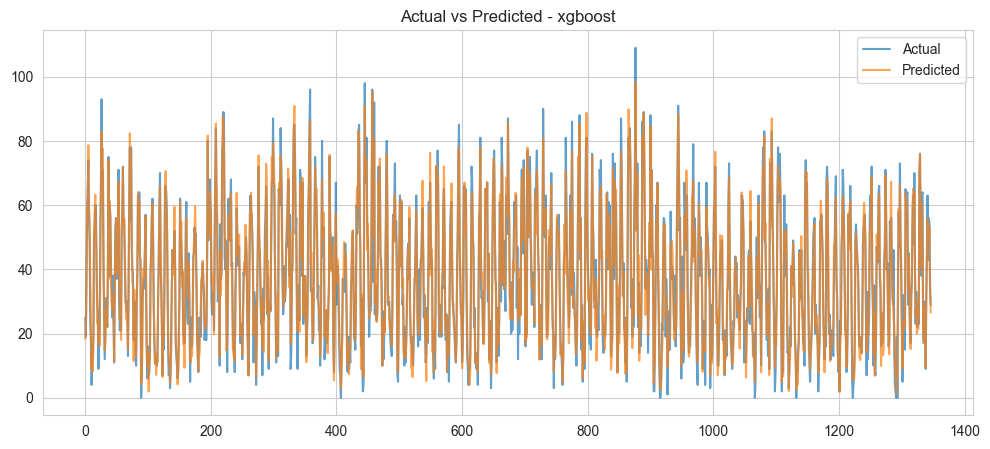

In [6]:
results = []
fitted_models = {}
for name, model in models.items():
    print(f'--- Training {name} ---')
    if name in ['linear','mlp']:
        Xtr, Xte = X_lin_train, X_lin_test
    else:
        Xtr, Xte = X_tree_train, X_tree_test
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f'RMSE: {rmse:.3f}  MAE: {mae:.3f}  R2: {r2:.3f}')
    results.append({'model': name, 'rmse': rmse, 'mae': mae, 'r2': r2})
    fitted_models[name] = model
    import os

model_save_path = r"C:\Users\lahar\Desktop\Model_Comparison_Submission\trained_models"
os.makedirs(model_save_path, exist_ok=True)

joblib.dump(model, os.path.join(model_save_path, f"model_{name}.joblib"))
# Summary
# Summary (only if results exist)
if len(results) > 0:

    res_df = pd.DataFrame(results).sort_values('rmse')
    print('\nSummary (sorted by RMSE):')
    display(res_df)

 # Summary
res_df = pd.DataFrame(results).sort_values('rmse')
print('\nSummary (sorted by RMSE):')
display(res_df)

# Save inside current notebook folder
res_df.to_csv("model_comparison_metrics.csv", index=False)

print("Comparison file saved successfully in current folder!")

best_name = res_df.iloc[0]['model'] if len(res_df)>0 else None
print(f'Best model by RMSE: {best_name}')
if best_name is not None:
    best_model = fitted_models[best_name]
    preds_best = best_model.predict(X_lin_test) if best_name in ['linear','mlp'] else best_model.predict(X_tree_test)
    plt.figure(figsize=(12,5))
    plt.plot(list(y_test.values), label='Actual', alpha=0.7)
    plt.plot(list(preds_best), label='Predicted', alpha=0.7)
    plt.legend()
    plt.title(f'Actual vs Predicted - {best_name}')
    plt.show()

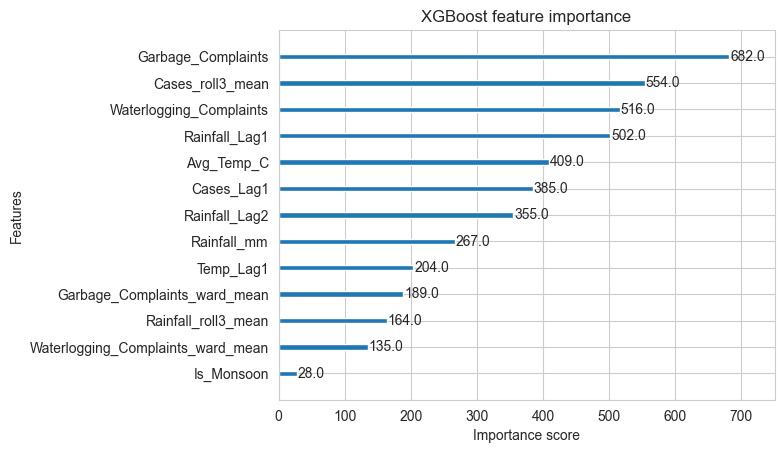

In [7]:
# Feature importance for tree models
if 'best_name' in globals() and best_name in ['random_forest','gbm','xgboost']:
    if best_name == 'xgboost' and HAS_XGB:
        xgb.plot_importance(best_model, max_num_features=15)
        plt.title('XGBoost feature importance')
        plt.show()
    else:
        try:
            imp = best_model.feature_importances_
            feat_names = X_tree_train.columns
            feat_imp = pd.Series(imp, index=feat_names).sort_values(ascending=False).head(15)
            plt.figure(figsize=(8,5))
            sns.barplot(x=feat_imp.values, y=feat_imp.index)
            plt.title(f'Feature importance: {best_name}')
            plt.show()
        except Exception as e:
            print('Could not plot feature importances:', e)
else:
    print('Best model is not tree-based; skipping importance plot.')

## Artifacts
Models and scaler are saved as `model_<name>.joblib` and `scaler.joblib`. Next steps: hyperparameter tuning and time-series cross-validation.